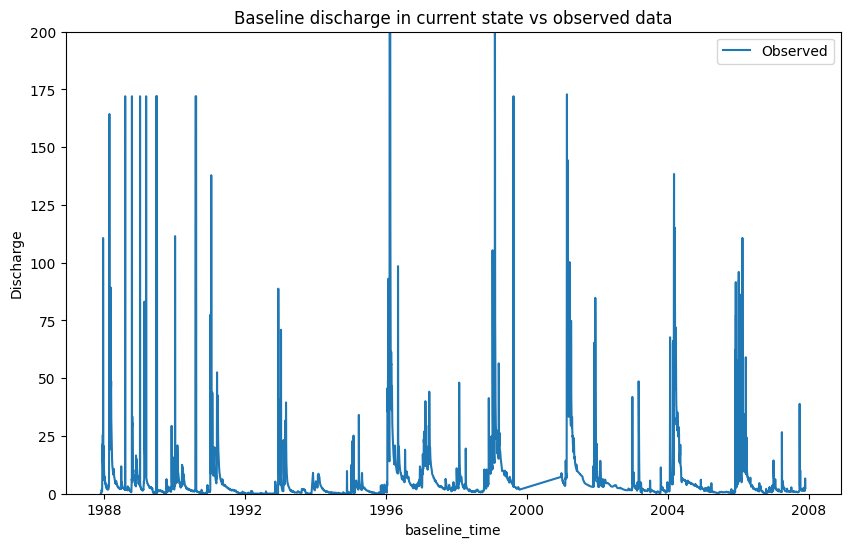

C:\Users\verwegen\AppData\Local\Temp\ipykernel_244\97785632.py:63: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_wrc = pd.read_csv(
C:\Users\verwegen\AppData\Local\Temp\ipykernel_244\97785632.py:131: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f, delim_whitespace=True, header=None, names=cols)
C:\Users\verwegen\AppData\Local\Temp\ipykernel_244\97785632.py:131: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f, delim_whitespace=True, header=None, names=cols)
C:\Users\verwegen\AppData\Local\Temp\ipykernel_244\97785632.py:131: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` inste

               value
date                
1919-10-31  3.061529
1919-11-30  3.750000
1919-12-31  3.039128
1920-01-31  2.658303
1920-02-29  8.796296


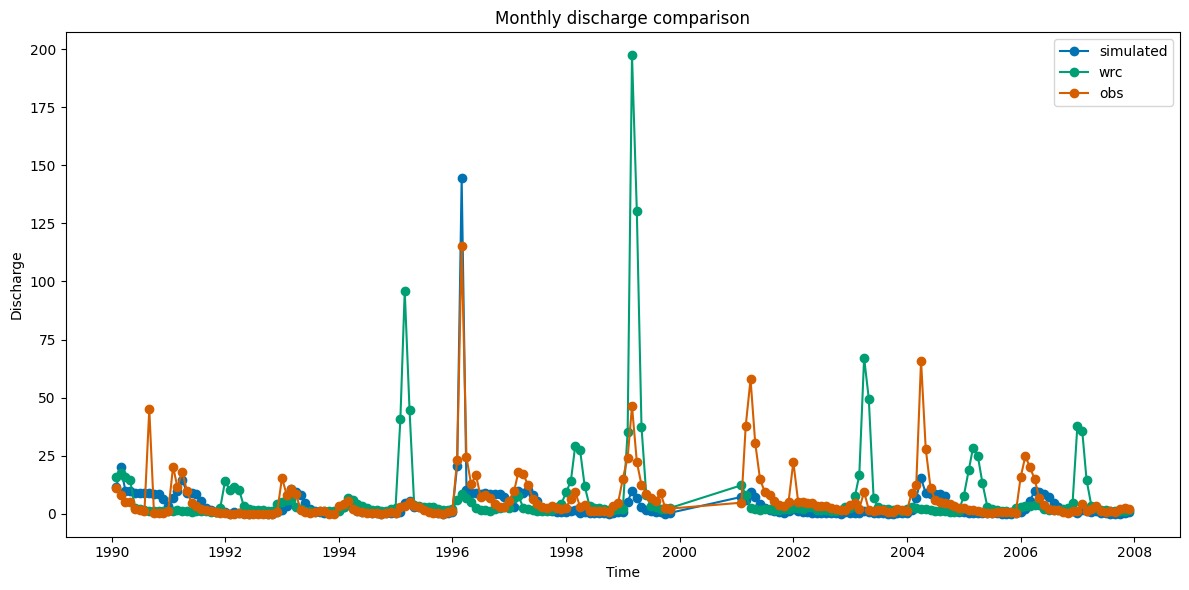

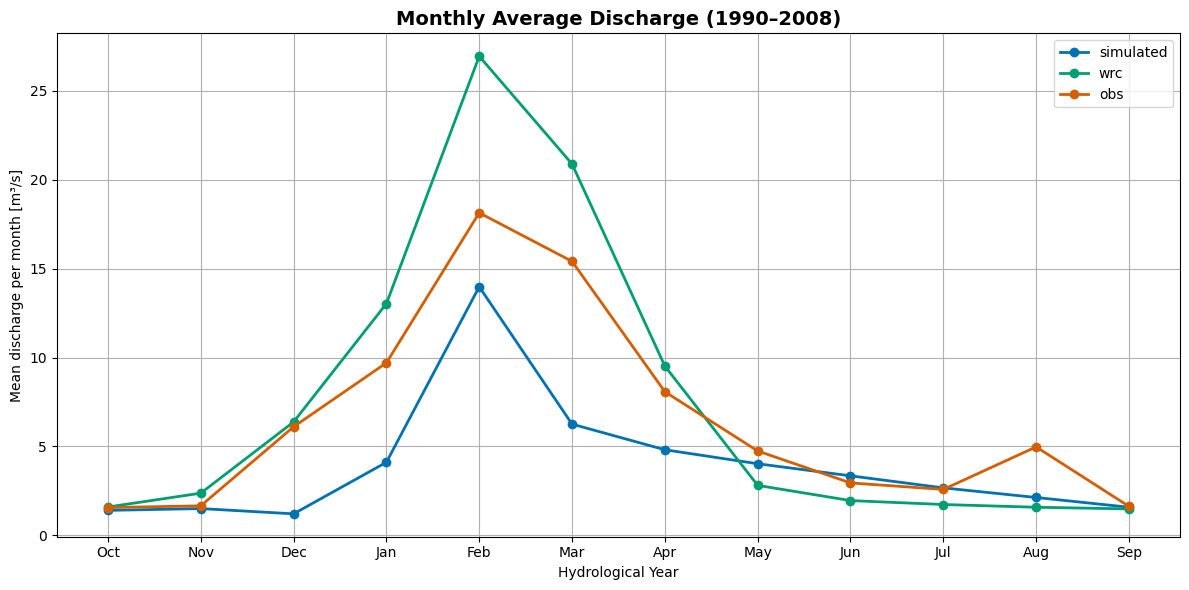

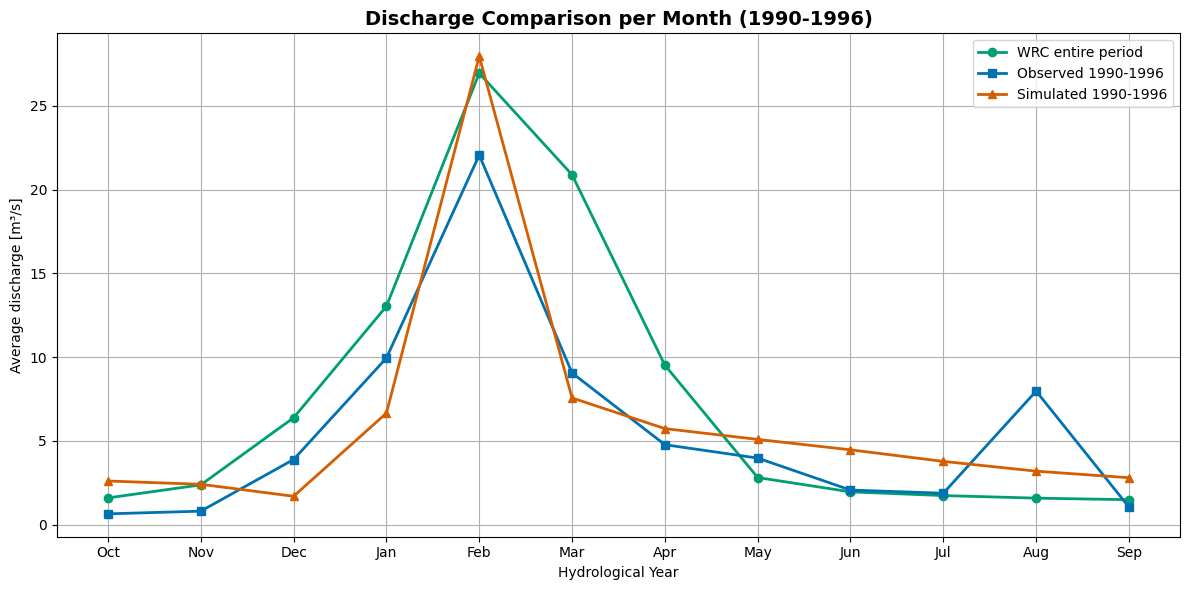

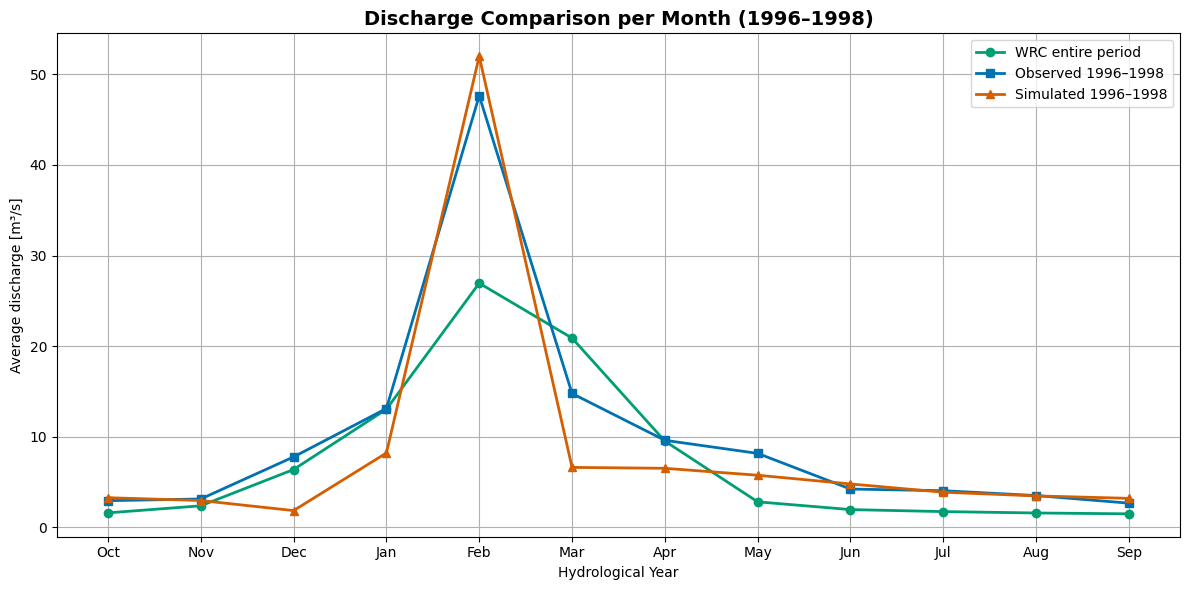

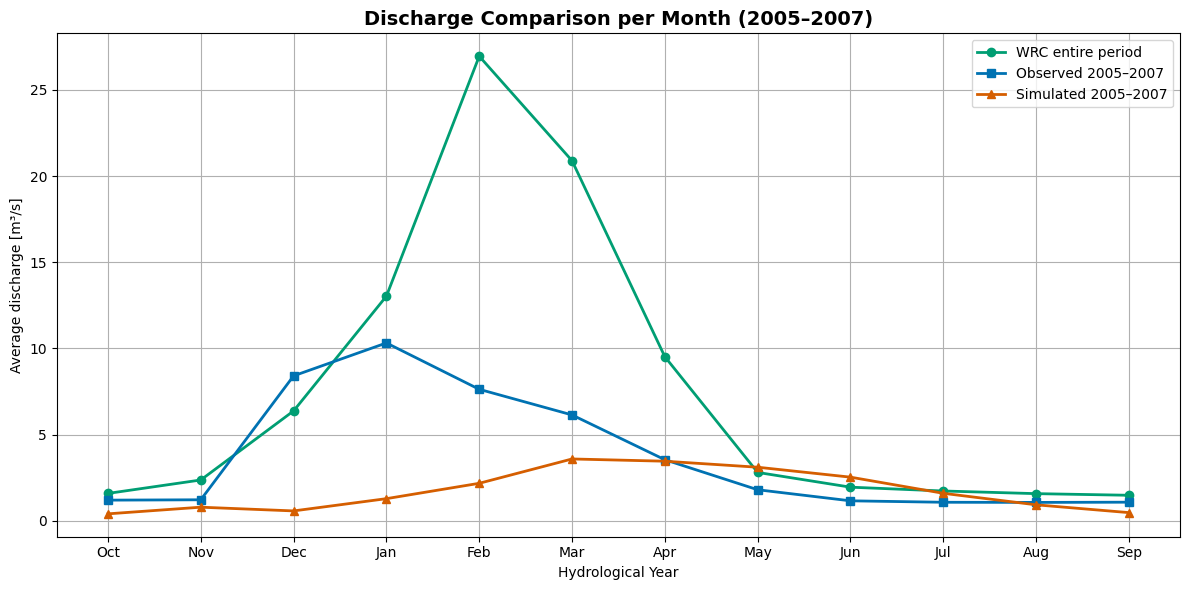

C:\Users\verwegen\AppData\Local\Temp\ipykernel_244\97785632.py:315: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly = df_all_clean.resample('Y').mean()


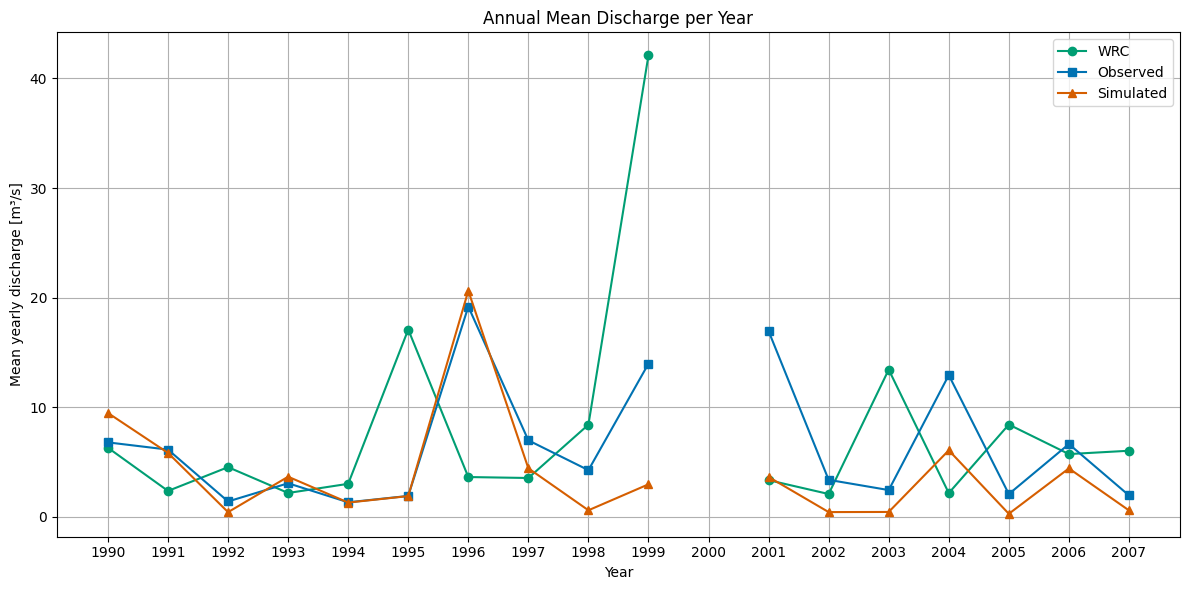

In [50]:
# -*- coding: utf-8 -*-
"""
Created on Wed Feb  4 16:27:40 2026

@author: verwegen
"""

#%%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import glob
import os
import matplotlib.patches as mpatches
# from brokenaxes import brokenaxes

#%% import observed


path = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing\Observed_A9H012_old_daily.txt"

df_obs_old = pd.read_csv(
    path,
    sep=r'\s+',
    usecols=[0, 1], 
    parse_dates=True, 
    index_col=0)

df_obs_old = df_obs_old[df_obs_old["obs"] != 170]

df_obs_old_month = df_obs_old.resample("ME").mean()

#%% quick plot of the observed data
plt.figure(figsize=(10,6))
plt.plot(df_obs_old.index, df_obs_old["obs"], 
         label= 'Observed', 
        #  marker = 'o'
         )
plt.xlabel("baseline_time")
plt.ylabel("Discharge")
plt.title("Baseline discharge in current state vs observed data")
plt.legend()
# plt.xlim(pd.to_datetime("2001-01-01"),
#          pd.to_datetime("2002-01-01"))
plt.ylim(0,200)
plt.show()


#%% import WRC old method

path1 = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing\WRC_A91H.ans"

# Adjusted columns to match your data: year, then Oct -> Sep
cols = [
    "year",
    "Oct", "Nov", "Dec",
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep",
    "annual"
]

df_wrc = pd.read_csv(
    path1,
    delim_whitespace=True,
    header=None,
    names=cols
)

# Melt with the same order
df_wrc_long = df_wrc.melt(
    id_vars="year",
    value_vars=[
        "Oct", "Nov", "Dec",
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep"
    ],
    var_name="month",
    value_name="value"
)

# Map months to numbers (calendar order)
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

df_wrc_long["month_num"] = df_wrc_long["month"].map(month_map)

# Adjust year for Oct-Dec, since they belong to the previous hydrological year
df_wrc_long["hydro_year"] = df_wrc_long["year"]
df_wrc_long.loc[df_wrc_long["month"].isin(["Oct", "Nov", "Dec"]), "hydro_year"] -= 1

df_wrc_long["date"] = pd.to_datetime(
    dict(
        year=df_wrc_long["hydro_year"],
        month=df_wrc_long["month_num"],
        day=1
    )
)

df_wrc_long = df_wrc_long.sort_values("date").set_index("date")[["value"]]

# Convert from MCM/month to m3/s
df_wrc_long_converted = df_wrc_long.copy()
seconds_per_month = df_wrc_long_converted.index.days_in_month * 24 * 3600
df_wrc_long_converted['value'] = df_wrc_long_converted['value'] * 1e6 / seconds_per_month

df_wrc_long = df_wrc_long_converted

# Optional: resample to month-end
df_wrc_long = df_wrc_long.resample("ME").mean()

#%% import all WRC datafiles and sum them

folder = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing"
files = sorted(glob.glob(os.path.join(folder, "A91*.ans")))

cols = [
    "year",
    "Oct", "Nov", "Dec",
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep",
    "annual"
]

dfs_long = []

for f in files:
    df = pd.read_csv(f, delim_whitespace=True, header=None, names=cols)
    
    # Convert years to numbers to melt the dataframe to
    df = df[df["year"].apply(lambda x: str(x).isdigit())]
    df["year"] = df["year"].astype(int)
    
    df_long = df.melt(
        id_vars="year",
        value_vars=[
            "Oct", "Nov", "Dec",
            "Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep"
        ],
        var_name="month",
        value_name="value"
    )
    
    month_map = {
        "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
        "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
        "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
    }
    df_long["month_num"] = df_long["month"].map(month_map)
    
    # Adjust year for Oct-Dec
    df_long["hydro_year"] = df_long["year"]
    df_long.loc[df_long["month"].isin(["Oct", "Nov", "Dec"]), "hydro_year"] -= 1
    
    # Remove data when incorrect
    df_long = df_long[df_long["hydro_year"] > 0]  # no negative values
    df_long["date"] = pd.to_datetime(
        dict(
            year=df_long["hydro_year"],
            month=df_long["month_num"],
            day=1
        )
    )
    
    df_long = df_long.sort_values("date").set_index("date")[["value"]]
    
    # Multiply A91H by 0,5
    if os.path.basename(f).startswith("A91H"):
        df_long["value"] / 2

    dfs_long.append(df_long)

# Sum all dfs
df_sum = pd.concat(dfs_long, axis=1).sum(axis=1).to_frame(name="value")

# Convert from MCM/month to m3/s
seconds_per_month = df_sum.index.days_in_month * 24 * 3600
df_sum["value"] = df_sum["value"] * 1e6 / seconds_per_month

# Resample to month-end
df_sum = df_sum.resample("ME").mean()

df_wrc_long = df_sum.copy()

print(df_sum.head())

#%% import simulated 

path2 = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing\Simulated_fitted.csv"

df_sim = pd.read_csv(
    path2,
    # parse_dates=[0],   # parse first column as datetime
    # index_col=0        # set first column as index
)

df_sim = df_sim.iloc[:, :2]
df_sim.dropna(inplace=True)
df_sim['baseline_time'] = pd.to_datetime(df_sim['baseline_time'])
df_sim = df_sim.set_index(df_sim['baseline_time'])
del(df_sim['baseline_time'])

df_sim_month = df_sim.resample("ME").mean()
df_sim_month = df_sim_month.rename(columns={"baseline": "simulated"})
#%%

df_all = (
    df_sim_month.rename(columns={"value": "sim"})
    .join(df_wrc_long.rename(columns={"value": "wrc"}), how="outer")
    .join(df_obs_old_month.rename(columns={"value": "obs"}), how="outer")
)

df_all_clean = df_all.dropna()
df_all_clean = df_all_clean[df_all_clean.index.year != 2000]

#%%

colors1 = ['#0072B2', '#009E73', '#D55E00'] 

fig, ax = plt.subplots(figsize=(12,6))

for col, color in zip(df_all_clean.columns, colors1):
    ax.plot(df_all_clean.index, df_all_clean[col], marker='o', linestyle='-', label=col, color=color)

ax.set_xlabel('Time')
ax.set_ylabel('Discharge')
ax.set_title('Monthly discharge comparison')
ax.legend()
plt.tight_layout()
plt.show()

#%% PLOTTING HYDROLOGICAL YEARS

# Colorblind-safe
colors = ['#009E73','#0072B2','#D55E00']    

# Hydrological year starting in October

hydro_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]

month_names_hydro = ['Oct', 'Nov', 'Dec','Jan', 'Feb', 'Mar',
                     'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep']

months = range(1, 13)

# Resampling
df = df_all_clean.copy()
df['month'] = df.index.month

# Entire period climatology
df_clim_full = df.groupby('month').mean().reindex(hydro_order)
wrc_clim = df.groupby('month')['wrc'].mean().reindex(hydro_order)

periods = {
    "1990-1996": (1990, 1996),
    "1996–1998": (1996, 1998),
    "2005–2007": (2005, 2007),
}

# plot all data compared to eachother before diving into comparing it over subsets
plt.figure(figsize=(12, 6))

for col, color in zip(df_clim_full.columns, colors1):
    plt.plot(months, df_clim_full[col],
             marker='o', linewidth=2, label=col, color=color)

plt.xticks(months, month_names_hydro)
plt.xlabel('Hydrological Year')
plt.ylabel('Mean discharge per month [m³/s]')
plt.title('Monthly Average Discharge (1990–2008)',
          fontsize=14, fontweight='bold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# plot over subset periods

for label, (start, end) in periods.items():

    subset = df[(df.index.year >= start) &
                (df.index.year <= end)]

    clim_period = subset.groupby('month')[['obs', 'simulated']].mean().reindex(hydro_order)

    plt.figure(figsize=(12, 6))

    plt.plot(months, wrc_clim,
             marker='o',linewidth=2,  label='WRC entire period', color = colors[0])

    plt.plot(months, clim_period['obs'], color = colors[1],
             marker='s',linewidth=2,  label=f'Observed {label}')

    plt.plot(months, clim_period['simulated'], color = colors[2],
             marker='^',linewidth=2,  label=f'Simulated {label}')

    plt.xticks(months, month_names_hydro)
    plt.xlabel('Hydrological Year')
    plt.ylabel('Average discharge [m³/s]')
    plt.title(f'Discharge Comparison per Month ({label})', fontsize=14, fontweight='bold')

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

#%% big differences over the annual averages visible

# Compute yearly mean discharge
df_yearly = df_all_clean.resample('Y').mean()

plt.figure(figsize=(12,6))

plt.plot(df_yearly.index.year, df_yearly['wrc'], color = colors[0], marker='o', label='WRC')
plt.plot(df_yearly.index.year, df_yearly['obs'], color = colors[1], marker='s', label='Observed')
plt.plot(df_yearly.index.year, df_yearly['simulated'], marker='^',color = colors[2], label='Simulated')

plt.xlabel('Year')
plt.ylabel('Mean yearly discharge [m³/s]')
plt.title('Annual Mean Discharge per Year')
plt.grid(True)
plt.legend()

years = df_yearly.index.year
step = max(1, len(years)//10)  # choose ~10 ticks
plt.xticks(years[::step])  # rotate labels for readability

plt.tight_layout()
plt.show()

#%% FFC







In [3]:
#%% FFC

from hydropattern.timeseries import Timeseries
from hydropattern.parsers import timing_parser, magnitude_parser, duration_parser, rate_of_change_parser
from hydropattern.patterns import Component, evaluate_component

# %%
dfs = []
df_all1 = df_all_clean.copy()
pd.to_datetime(df_all1.index)
df_all1.index.names = ['time']

df_wrc = df_all1[['wrc']]
df_obs = df_all1[['obs']]
df_sim = df_all1[['simulated']]

ts_wrc = Timeseries.from_dataframe(df_wrc, first_dowy=304)
ts_obs = Timeseries.from_dataframe(df_obs, first_dowy=304)
ts_sim = Timeseries.from_dataframe(df_sim, first_dowy=304)


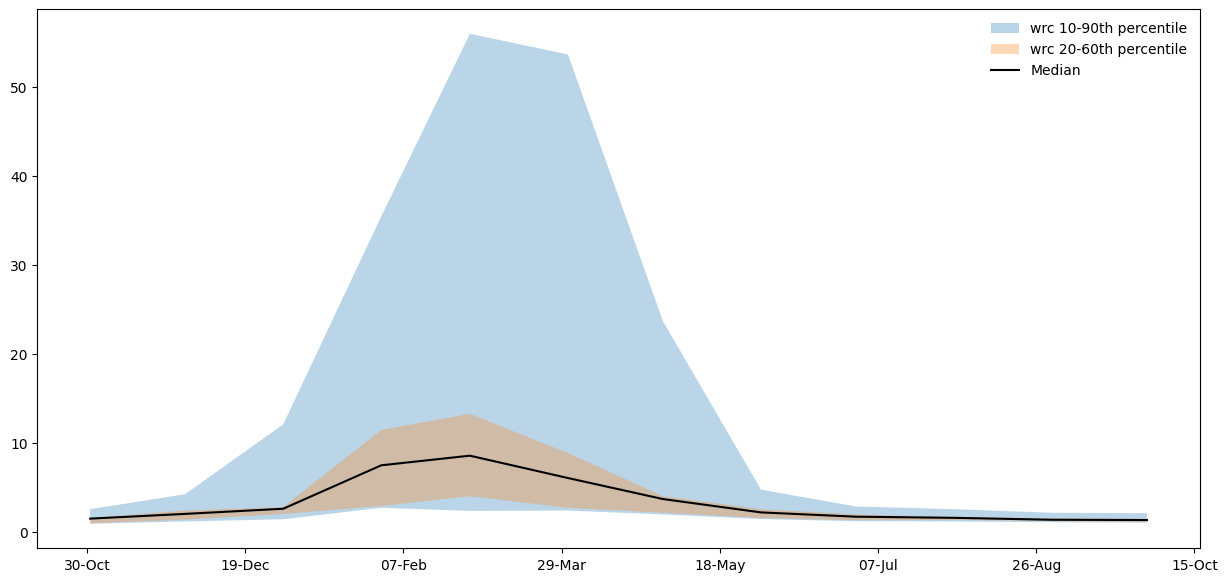

In [4]:
ts_wrc.plot_hydrograph_quantiles(rolling_periods=1, quantiles=[0.1, 0.2, 0.5, 0.6, 0.9],
                             )

In [5]:
# rate of change part
timing = timing_parser(
    metrics=[ts_wrc.month_day_year_to_day_of_water_year(month=4, day=30),
             ts_wrc.month_day_year_to_day_of_water_year(month=5, day=31)],
    order=1) 
rate_of_change = rate_of_change_parser(
    metrics= [">", 0.9], 
    order = 2
    )                    
# magnitude = magnitude_parser(
#     metrics=[10, 100],
#     order=2)                       # flow between 10 and 100
# duration = duration_parser(
#     metrics=[">", 10],
#     order=3)                       # for at least 10 days (time periods)
print(f'{timing}\n {rate_of_change}\n')

Characteristic(name='timing_182-213', fx=<function timing_fx.<locals>.closure at 0x000001C4911AD170>, type=<CharacteristicType.TIMING: 'timing'>)
 Characteristic(name='rate_of_change_gt0.9', fx=<function rate_of_change_fx.<locals>.closure at 0x000001C4911EA2A0>, type=<CharacteristicType.RATE_OF_CHANGE: 'rate_of_change'>)



In [6]:
# 
timing1 = timing_parser(
    metrics=[ts_wrc.month_day_year_to_day_of_water_year(month=6, day=30),
             ts_wrc.month_day_year_to_day_of_water_year(month=9, day=30)],
    order=1) 
# rate_of_change = rate_of_change_parser(
#     metrics= [">", 0.3], 
#     order = 2)                    
magnitude1 = magnitude_parser(
    metrics=[0.8, 3.5],
    order=2)                       # flow between 10 and 100
duration1 = duration_parser(
    metrics=[">", 20],
    order=3)                       # for at least 10 days (time periods)
print(f'{timing1}\n {magnitude1}\n')

Characteristic(name='timing_243-335', fx=<function timing_fx.<locals>.closure at 0x000001C4911AD2D0>, type=<CharacteristicType.TIMING: 'timing'>)
 Characteristic(name='magnitude_0.8-3.5', fx=<function magnitude_fx.<locals>.closure at 0x000001C4911E9E80>, type=<CharacteristicType.MAGNITUDE: 'magnitude'>)



In [7]:
# build the invasive species flow component

invasive = Component(name='invasive', 
                     characteristics=[timing, rate_of_change], 
                     is_success_pattern=True)
print(invasive)

base_flow_dry = Component(name='base_flow_dry', 
                     characteristics=[timing1, magnitude1, duration1], 
                     is_success_pattern=True)
print(base_flow_dry)

Component(name='invasive', characteristics=[Characteristic(name='timing_182-213', fx=<function timing_fx.<locals>.closure at 0x000001C4911AD170>, type=<CharacteristicType.TIMING: 'timing'>), Characteristic(name='rate_of_change_gt0.9', fx=<function rate_of_change_fx.<locals>.closure at 0x000001C4911EA2A0>, type=<CharacteristicType.RATE_OF_CHANGE: 'rate_of_change'>)], is_success_pattern=True)
Component(name='base_flow_dry', characteristics=[Characteristic(name='timing_243-335', fx=<function timing_fx.<locals>.closure at 0x000001C4911AD2D0>, type=<CharacteristicType.TIMING: 'timing'>), Characteristic(name='magnitude_0.8-3.5', fx=<function magnitude_fx.<locals>.closure at 0x000001C4911E9E80>, type=<CharacteristicType.MAGNITUDE: 'magnitude'>), Characteristic(name='duration_gt20', fx=<function duration_fx.<locals>.closure at 0x000001C4911EA8D0>, type=<CharacteristicType.DURATION: 'duration'>)], is_success_pattern=True)


In [8]:
print(f"Scenario{invasive}")

ScenarioComponent(name='invasive', characteristics=[Characteristic(name='timing_182-213', fx=<function timing_fx.<locals>.closure at 0x000001C4911AD170>, type=<CharacteristicType.TIMING: 'timing'>), Characteristic(name='rate_of_change_gt0.9', fx=<function rate_of_change_fx.<locals>.closure at 0x000001C4911EA2A0>, type=<CharacteristicType.RATE_OF_CHANGE: 'rate_of_change'>)], is_success_pattern=True)


In [9]:
result_sim = evaluate_component(ts_sim.data, base_flow_dry)
result_sim.df.head(10)

,dv,dowy,timing_243-335,magnitude_0.8-3.5,duration_gt20,base_flow_dry
time,,,,,,
1990-01-31,11.591503,93,0,0,0,0
1990-02-28,19.975664,121,0,0,0,0
1990-03-31,9.836678,152,0,0,0,0
1990-04-30,9.662943,182,0,0,0,0
1990-05-31,9.033686,213,0,0,0,0
1990-06-30,8.975822,243,1,0,0,0
1990-07-31,8.920222,274,1,0,0,0
1990-08-31,8.862016,305,1,0,0,0
1990-09-30,8.642093,335,1,0,0,0


In [104]:
# CLIMATE SCENARIOS
# Lets make a function that divides a dataframe into seperate timeseries sets with a defined first day 

def scenarios_for_components(dataframe, component, first_dowy=304):

    df = dataframe.copy()
    pd.to_datetime(df.index)
    df.index.name = 'time'
    results = {}

    # split all columns into seperate dataframes
    for i in df.columns:
        single_scenario = df[[i]]
        single_scenario

        ts = Timeseries.from_dataframe(single_scenario, first_dowy=first_dowy)
        result = evaluate_component(ts.data, component) # the result here is (df, component)
                                                        # to get to df --> result.df.head()

        # now append single scenario to the dictionary
        results[f"Scenario_{i}"] = result

    return results


In [105]:
path2 = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing\Simulated_fitted.csv"

df_sim = pd.read_csv(
    path2,
    # parse_dates=[0],   # parse first column as datetime
    # index_col=0        # set first column as index
)
df_sim = df_sim.iloc[:, 2:]
df_sim.dropna(inplace=True)
df_sim['time'] = pd.to_datetime(df_sim['time'])
df_sim = df_sim.set_index(df_sim['time'])
del(df_sim['time'])

In [106]:
scenario_base_flow_dry = scenarios_for_components(df_sim, base_flow_dry, first_dowy=304)

In [109]:
scenario_base_flow_dry['Scenario_rlz_1_cst_3'].df['dv'].max()

np.float64(644.8146542)

<Axes: xlabel='time'>

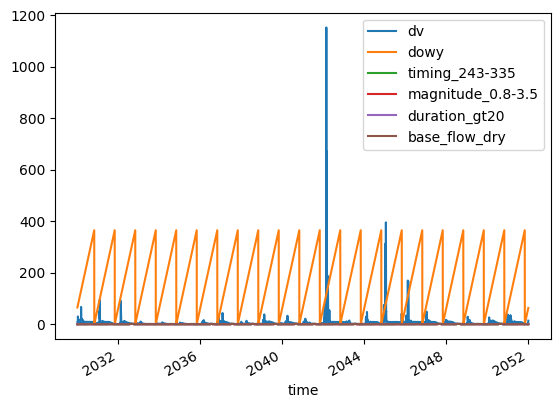

In [108]:
scenario_base_flow_dry['Scenario_rlz_2_cst_7'].df.plot()

In [83]:
test1 = scenario_base_flow_dry['Scenario_rlz_1_cst_1'].frequency_table(by_water_years=True).round(decimals=0)
test2 = scenario_base_flow_dry['Scenario_rlz_1_cst_6'].frequency_table(by_water_years=True).round(decimals=0)

In [84]:
test1.head(2)


,T,timing_243-335,timing_243-335(%),magnitude_0.8-3.5,magnitude_0.8-3.5(%),duration_gt20,duration_gt20(%),base_flow_dry,base_flow_dry(%)
total,8029,2046,25.0,364,5.0,283,4.0,283,4.0
2030,363,93,26.0,0,0.0,0,0.0,0,0.0


In [85]:
test2['base_flow_dry(%)'].iloc[0].item()

8.0

In [86]:
rows = []

for key in scenario_base_flow_dry:
    values = scenario_base_flow_dry[key].frequency_table(by_water_years=True).round(decimals=0)
    score = values['base_flow_dry(%)'].iloc[0].item()

    rows.append({'scenario': key, 'score': score})

# Create dataframe
scores_df = pd.DataFrame(rows)

print(scores_df.head())


                scenario  score
0   Scenario_rlz_1_cst_1    4.0
1  Scenario_rlz_1_cst_10    6.0
2  Scenario_rlz_1_cst_11    8.0
3  Scenario_rlz_1_cst_12    8.0
4  Scenario_rlz_1_cst_13    8.0


In [87]:
scores_df[['rlz','cst']] = scores_df['scenario'].str.extract(r'rlz_(\d+)_cst_(\d+)').astype(int)
scores_df = scores_df.sort_values(['rlz','cst'])
scores_df.head(10)

,scenario,score,rlz,cst
0,Scenario_rlz_1_cst_1,4.0,1,1
11,Scenario_rlz_1_cst_2,5.0,1,2
21,Scenario_rlz_1_cst_3,6.0,1,3
22,Scenario_rlz_1_cst_4,8.0,1,4
23,Scenario_rlz_1_cst_5,8.0,1,5
24,Scenario_rlz_1_cst_6,8.0,1,6
25,Scenario_rlz_1_cst_7,8.0,1,7
26,Scenario_rlz_1_cst_8,4.0,1,8
27,Scenario_rlz_1_cst_9,5.0,1,9
1,Scenario_rlz_1_cst_10,6.0,1,10


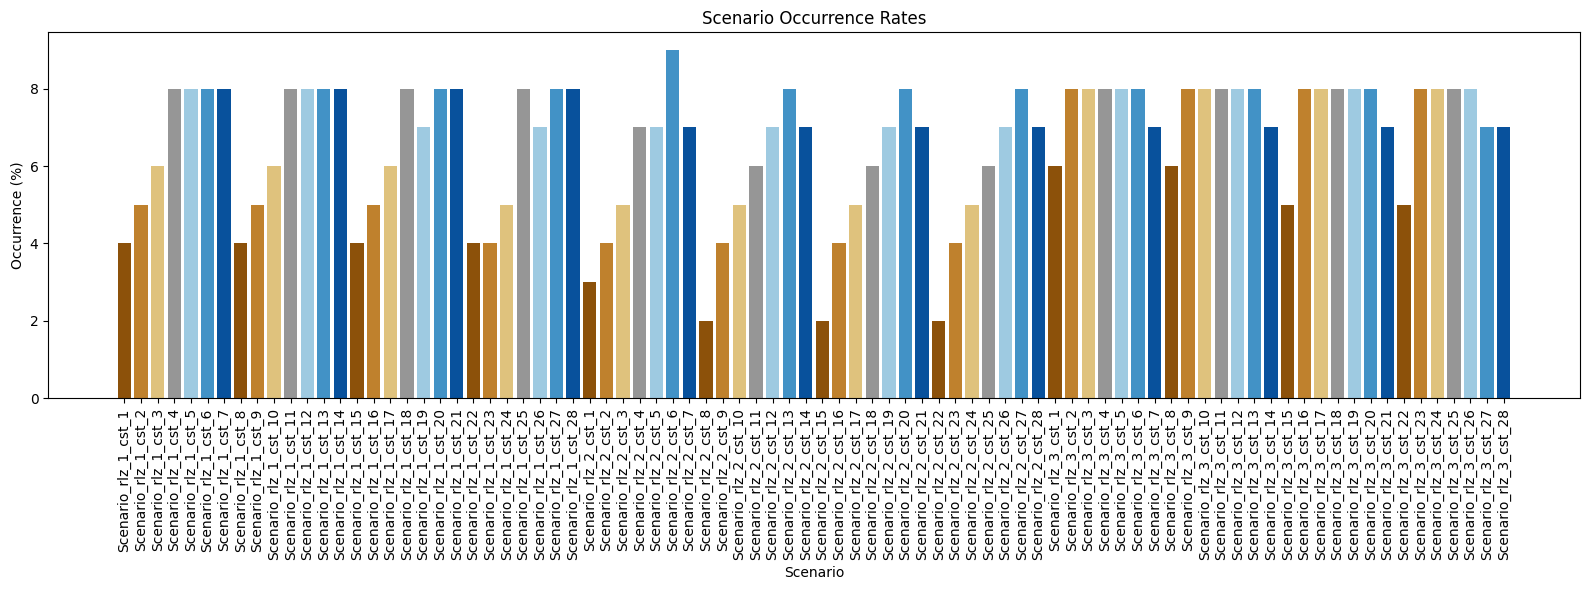

In [88]:
#everything combined

dry_colors = ["#8c510a", "#bf812d", "#dfc27d"]   # dark → light brown
normal = "#969696" 
wet_colors = ["#9ecae1", "#4292c6", "#08519c"]   # light → strong blue

pattern = dry_colors + [normal] + wet_colors
colors = pattern * 3   # 3 realizations

plt.figure(figsize=(16,6))

plt.bar(scores_df['scenario'], scores_df['score'], color=colors)

plt.xlabel('Scenario')
plt.ylabel('Occurrence (%)')
plt.title('Scenario Occurrence Rates')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [89]:
scores_df[['rlz','cst']] = scores_df['scenario'].str.extract(r'rlz_(\d+)_cst_(\d+)').astype(int)

# warming scenario from CST number
scores_df['warming'] = (scores_df['cst']-1)//7

# scenario type within each warming block (1–7)
scores_df['type'] = (scores_df['cst']-1)%7 + 1


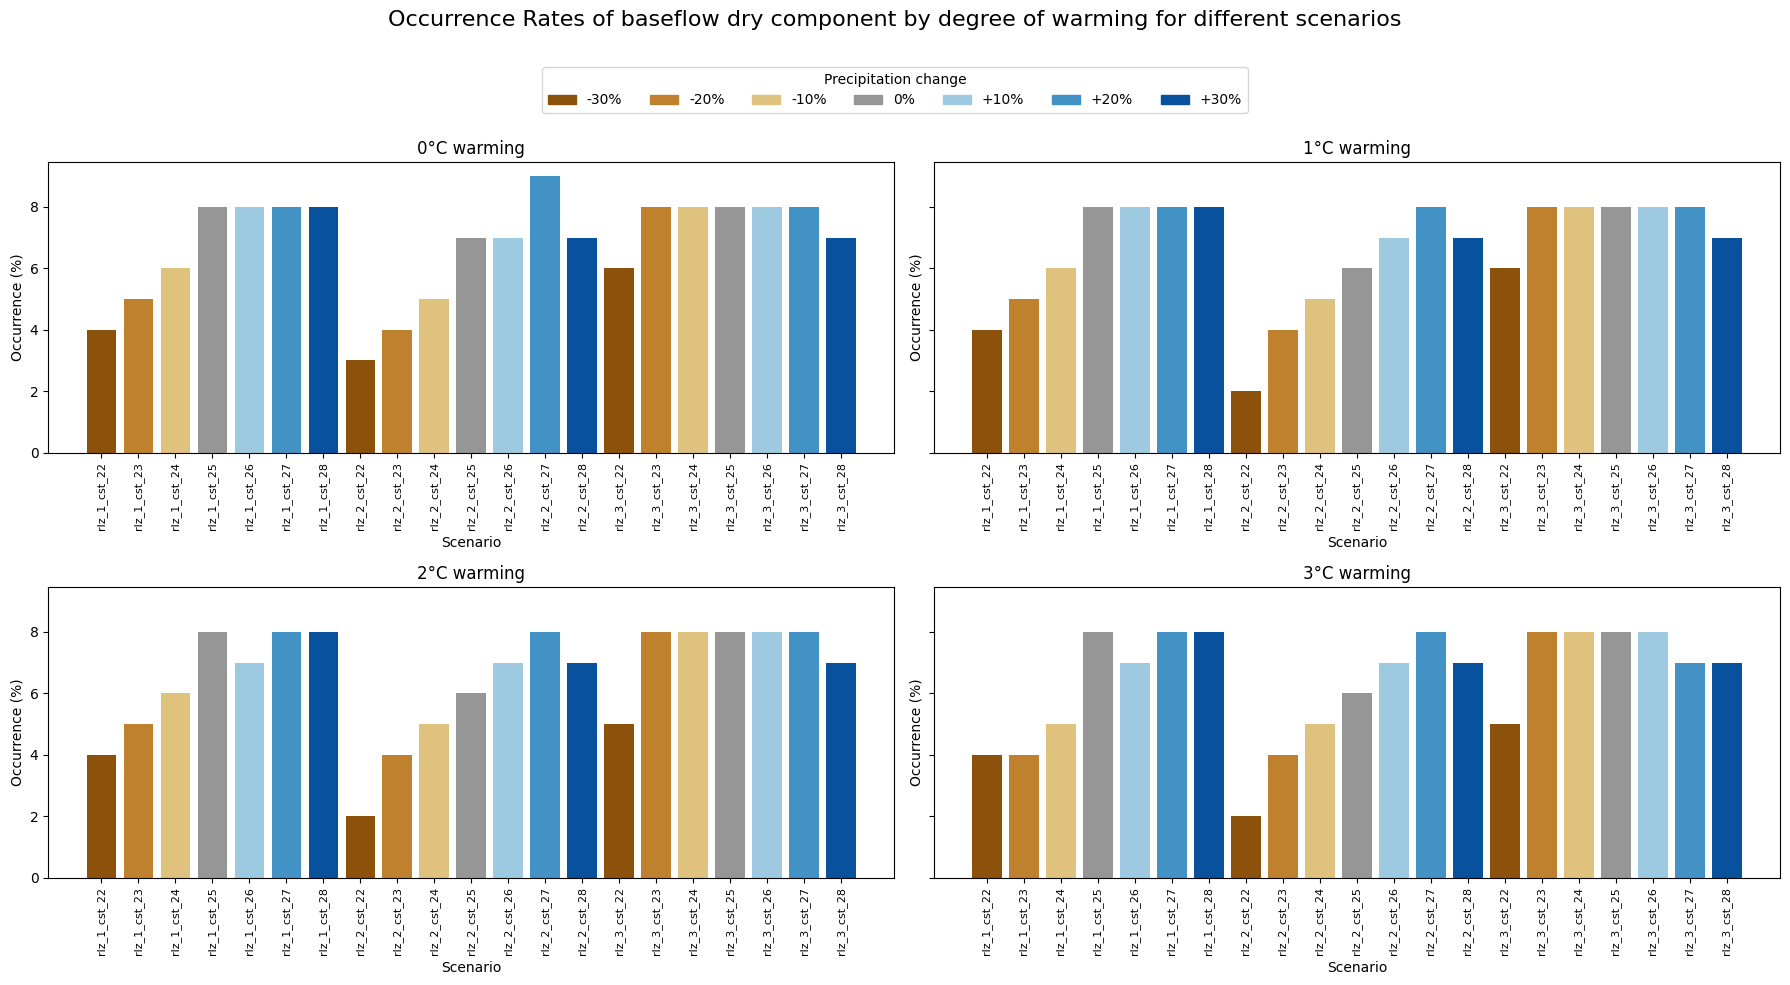

In [90]:
legend_handles = [
    mpatches.Patch(color=dry_colors[0], label="-30%"),
    mpatches.Patch(color=dry_colors[1], label="-20%"),
    mpatches.Patch(color=dry_colors[2], label="-10%"),
    mpatches.Patch(color=normal, label="0%"),
    mpatches.Patch(color=wet_colors[0], label="+10%"),
    mpatches.Patch(color=wet_colors[1], label="+20%"),
    mpatches.Patch(color=wet_colors[2], label="+30%"),
]

fig, axes = plt.subplots(2, 2, figsize=(18,10), sharey=True)
fig.legend(
    handles=legend_handles,
    title="Precipitation change",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=7
)

warming_levels = [0,1,2,3]
labels = df_w['scenario'].str.replace('Scenario_', '', regex=False)

for ax, w in zip(axes.flat, warming_levels):

    df_w = scores_df[scores_df['warming']==w].sort_values(['rlz','type'])

    x = range(len(df_w))
    colors = pattern * 3   # 3 realizations

    ax.bar(x, df_w['score'], color=colors)

    ax.set_title(f'{w}°C warming')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Occurrence (%)")

plt.suptitle("Occurrence Rates of baseflow dry component by degree of warming for different scenarios", fontsize=16)

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

In [129]:
test_df = scenario_base_flow_dry['Scenario_rlz_1_cst_3'].df.iloc[:,:1]
test_df

,dv
time,
2030-01-03,0.000289
2030-01-04,0.675203
2030-01-05,8.523085
2030-01-06,8.570473
2030-01-07,8.554425
...,...
2051-12-28,1.003926
2051-12-29,0.897453
2051-12-30,0.792968


C:\Users\verwegen\AppData\Local\Temp\ipykernel_244\4282179871.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['year'] = test_df.index.year
C:\Users\verwegen\AppData\Local\Temp\ipykernel_244\4282179871.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['day_of_year'] = test_df.index.dayofyear


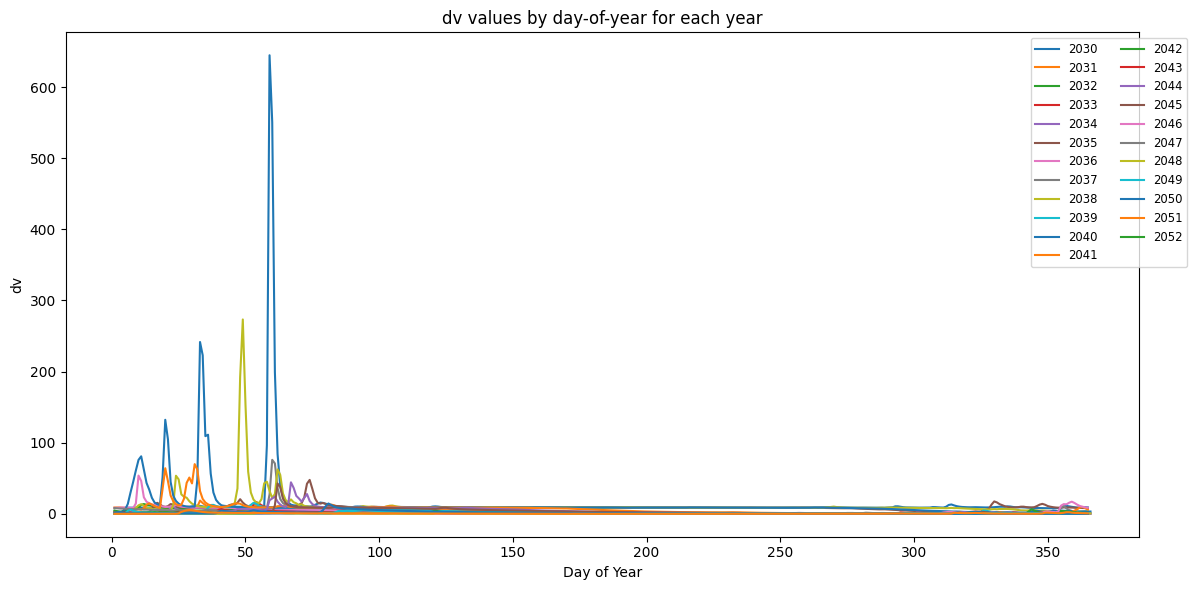

In [136]:
# Add year and day-of-year columns
test_df['year'] = test_df.index.year
test_df['day_of_year'] = test_df.index.dayofyear

plt.figure(figsize=(12, 6))

# Plot each year
for year, group in test_df.groupby('year'):
    plt.plot(group['day_of_year'], group['dv'], label=str(year))

plt.xlabel('Day of Year')
plt.ylabel('dv')
plt.title('dv values by day-of-year for each year')
plt.legend(fontsize='small', ncol=2, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
df_freq_obs = result_obs1.frequency_table(by_water_years=True)
df_freq_wrc = result_wrc1.frequency_table(by_water_years=True)
df_freq_sim = result_sim1.frequency_table(by_water_years=True)


NameError: name 'result_obs1' is not defined

In [ ]:
df_round_freq_obs = df_freq_obs.round(decimals=0)
df_round_freq_wrc = df_freq_wrc.round(decimals=0)
df_round_freq_sim = df_freq_sim.round(decimals=0)

In [ ]:
df_round_freq_obs.to_csv("C:/Users/verwegen/Thesis/Data/Luvuvhu/Comparing/Output/first_component_obs.csv")
df_round_freq_wrc.to_csv("C:/Users/verwegen/Thesis/Data/Luvuvhu/Comparing/Output/first_component_wrc.csv")
df_round_freq_sim.to_csv("C:/Users/verwegen/Thesis/Data/Luvuvhu/Comparing/Output/first_component_sim.csv")



In [18]:
path = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing\Observed_A9H012_old_daily.txt"

df_obs_old = pd.read_csv(
    path,
    sep=r'\s+',
    usecols=[0, 1], 
    parse_dates=True, 
    index_col=0)

pd.to_datetime(df_obs_old.index)
df_obs_old.index.names = ['time']

df_obs_old = df_obs_old[df_obs_old["obs"] != 170]

df_obs_good = df_obs_old.loc['1990':'1998']

ts_df_obs = Timeseries.from_dataframe(df_obs_good, first_dowy=304)


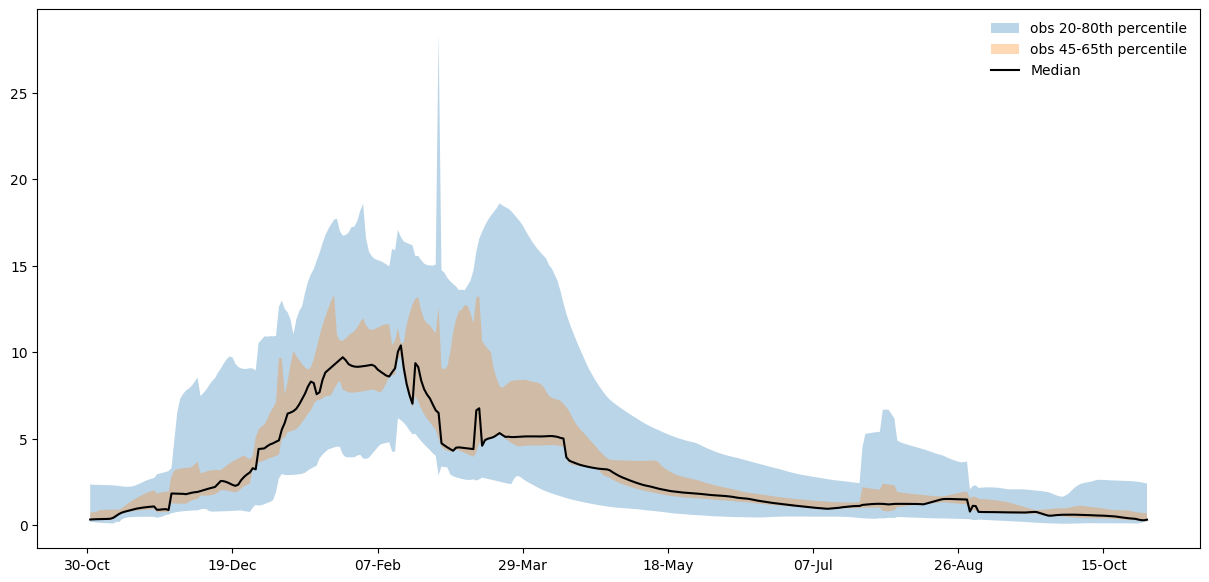

In [19]:
ts_df_obs.plot_hydrograph_quantiles(rolling_periods=30, quantiles=[0.2, 0.45, 0.5, 0.65, 0.8],
                             )